## Similitud - Evaluación LSH

Se compara LSH contra fuerza bruta en un solo mes para justificar `(B, R)` antes de la corrida completa

- Como en lab4 (Act. 02 y 04): ground truth exacto y precision / recall / F1 de los candidatos LSH

- Experimentos (3 valores cada uno): parámetros `(b, r)`, longitud de la firma `T`, número de cubetas y `UMBRAL` de Jaccard

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
firmas_dir = proyecto / "02_Similitud" / "temp" / "a_minhash" / "firmas"
out_dir = proyecto / "02_Similitud" / "temp" / "b_lsh"
out_dir.mkdir(parents=True, exist_ok=True)

- Funciones

Parámetros y funciones compartidas de `02_Similitud/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-evaluacion-lsh")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Mes de análisis

Se cargan el mes y el siguiente (partition pruning). Cambiar `ANIO_CHK, MES_CHK` para revisar otro mes

In [7]:
assert firmas_dir.exists(), f"No se encuentra {firmas_dir}; corre a_minhash.ipynb"
ANIO_CHK, MES_CHK = 2024, 6   # mes intermedio con volumen típico de procesos y muchos pares reales para medir recall,
                              # lejos del pico atípico de OEFA (feb–mar 2025)

procesos = spark.read.parquet(str(final_dir)).select(*COLS_SIMILITUD)
firmas   = spark.read.parquet(str(firmas_dir))

if not procesos.where((F.col("anio") == ANIO_CHK) & (F.col("mes") == MES_CHK)).limit(1).count():
    f0 = procesos.select("anio", "mes").distinct().orderBy("anio", "mes").first()
    ANIO_CHK, MES_CHK = f0["anio"], f0["mes"]
    print(f"Mes no disponible; se usa {ANIO_CHK}-{MES_CHK:02d}")

proc_m   = procesos.where(filtro_meses(ANIO_CHK, MES_CHK)).select("ocid", "entidad", "fecha", "anio", "mes", "shingles").cache()
firmas_m = firmas.where(filtro_meses(ANIO_CHK, MES_CHK)).cache()
print(f"{ANIO_CHK}-{MES_CHK:02d} + mes siguiente: {proc_m.count():,} procesos, {firmas_m.count():,} firmas")

2024-06 + mes siguiente: 13,696 procesos, 13,696 firmas


### 2. Ground truth exacto

Jaccard de **todos** los pares de la misma entidad dentro de la ventana, sin LSH (fuerza bruta, solo para este mes)

In [8]:
a, b = proc_m.alias("a"), proc_m.alias("b")
cond_gt = ((F.col("a.entidad") == F.col("b.entidad")) & orden_par("a", "b") &
           (F.datediff(F.col("b.fecha"), F.col("a.fecha")) <= VENTANA_DIAS) &
           (F.col("a.anio") == ANIO_CHK) & (F.col("a.mes") == MES_CHK))
t0 = time.time()
gt = (a.join(b, cond_gt).select(F.col("a.ocid").alias("ocid_1"), F.col("b.ocid").alias("ocid_2"),
                                jaccard_exacto(F.col("a.shingles"), F.col("b.shingles")).alias("jaccard")).cache())
n_gt = gt.count(); gt_pos = gt.where(F.col("jaccard") >= UMBRAL).cache(); n_pos = gt_pos.count()
print(f"Pares exactos en la ventana: {n_gt:,} | con Jaccard ≥ {UMBRAL}: {n_pos:,} | {time.time() - t0:.1f} s")

Pares exactos en la ventana: 212,632 | con Jaccard ≥ 0.9: 8,334 | 3.3 s


### 3. Experimento: parámetros `(b, r)`

- `candidatos` = pares que LSH propone

- `FP` se descartan al verificar (cuestan tiempo); `FN` son pares reales que LSH **pierde**

- Auxiliar

In [9]:
def metricas_lsh(b, r, firmas_df=None, n_cubetas=None, umbral=UMBRAL):
    # firmas_df / n_cubetas / umbral permiten reusarla en los experimentos; por defecto: firmas de a_minhash, 2³² cubetas y UMBRAL
    t0 = time.time()
    firmas_df = firmas_m if firmas_df is None else firmas_df
    gt_u = gt.where(F.col("jaccard") >= umbral)
    n_u = gt_u.count()
    cands = candidatos_lsh(lsh_bandas(firmas_df, b, r, n_cubetas), ANIO_CHK, MES_CHK)
    n_c = cands.count()
    tp = cands.join(gt_u, ["ocid_1", "ocid_2"]).count()
    fp, fn = n_c - tp, n_u - tp
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {"b": b, "r": r, "umbral_lsh": round((1 / b) ** (1 / r), 3), "candidatos": n_c, "GT": n_u,
            "TP": tp, "FP": fp, "FN": fn, "precision": round(prec, 4), "recall": round(rec, 4), "F1": round(f1, 4), "seg": round(time.time() - t0, 1)}

- Flujo

In [10]:
# 3 configuraciones con b·r = T = 100; umbral LSH (1/b)^(1/r): 0.55 (permisiva), 0.79 (elegida) y 0.92 (estricta, sobre UMBRAL)
configs = [(20, 5), (10, 10), (5, 20)]
tabla = pd.DataFrame([metricas_lsh(b_, r_) for b_, r_ in configs])
print(f"Fuerza bruta: {n_gt:,} comparaciones")
tabla

Fuerza bruta: 212,632 comparaciones


,b,r,umbral_lsh,candidatos,GT,TP,FP,FN,precision,recall,F1,seg
0,20,5,0.549,29567,8334,8334,21233,0,0.2819,1.0000,0.4398,2.2
1,10,10,0.794,10209,8334,8334,1875,0,0.8163,1.0000,0.8989,1.1
2,5,20,0.923,8366,8334,8314,52,20,0.9938,0.9976,0.9957,0.7


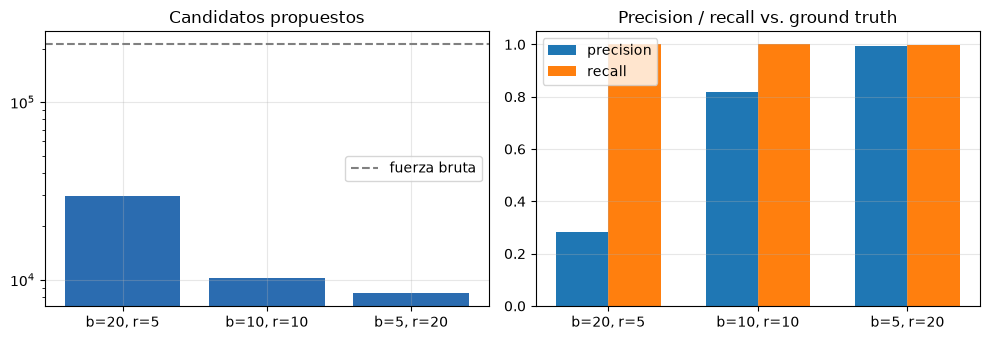

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = [f"b={b_}, r={r_}" for b_, r_ in configs]
ax[0].bar(x, tabla["candidatos"], color="#2b6cb0"); ax[0].axhline(n_gt, color="gray", ls="--", label="fuerza bruta"); ax[0].set_yscale("log")
ax[0].set_title("Candidatos propuestos"); ax[0].legend()
w = .35; i = np.arange(len(x))
ax[1].bar(i - w / 2, tabla["precision"], w, label="precision"); ax[1].bar(i + w / 2, tabla["recall"], w, label="recall")
ax[1].set_xticks(i); ax[1].set_xticklabels(x); ax[1].set_title("Precision / recall vs. ground truth"); ax[1].legend()
mostrar_fig("lsh_configs")

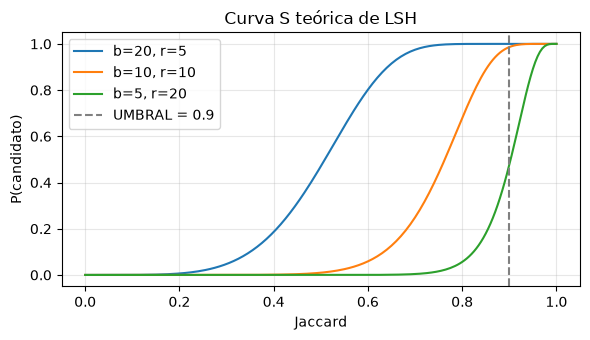

In [12]:
# curva S teórica: P(candidato) = 1 − (1 − sʳ)ᵇ para un par con Jaccard s
s = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(6, 3.5))
for b_, r_ in configs:
    ax.plot(s, 1 - (1 - s ** r_) ** b_, label=f"b={b_}, r={r_}")
ax.axvline(UMBRAL, color="gray", ls="--", label=f"UMBRAL = {UMBRAL}")
ax.set_xlabel("Jaccard"); ax.set_ylabel("P(candidato)"); ax.set_title("Curva S teórica de LSH"); ax.legend()
mostrar_fig("curva_s")

- `(10, 10)`: umbral LSH 0.79 < 0.90 → 10,209 candidatos frente a 212,632 comparaciones de fuerza bruta (−95%); encuentra los 8,334 pares reales (recall 100%, precision 0.82)

- `(5, 20)`: mejor F1 (0.996), pero con umbral 0.92 pierde 20 pares reales del rango 0.90–0.92

- `(20, 5)`: umbral 0.55 → casi 3 veces más candidatos (precision 0.28) sin ganar recall

- La curva S lo explica: con `r` bajo sube antes y deja pasar pares de Jaccard medio; con `r` alto sube después de 0.90 y pierde pares reales

- Se fija `(B, R) = (10, 10)`: un falso positivo solo cuesta tiempo de verificación; un falso negativo se pierde

### 4. Experimento: longitud de la firma `T`

- Se recalculan las firmas del mes con `T` = 50, 100 y 200 (`r = 10` fijo y `b = T / 10`, para que el umbral LSH quede cerca de 0.79 en los tres)

- Se mide el error de MinHash frente al Jaccard exacto, el tiempo de las firmas y el resultado de LSH

In [13]:
EXP_T = [50, 100, 200]     # mitad, actual y doble; umbral LSH (1/b)^(1/10): 0.85, 0.79 y 0.74
muestra_gt = gt.sample(fraction=min(1.0, 3000 / n_gt), seed=SEED).cache()   # ~3,000 pares de la ventana para medir el error

filas = []
for t_ in EXP_T:
    t0 = time.time()
    a_c, b_c = generar_coeficientes(t=t_)
    f_t = firmar(codificar_shingles(proc_m), a_c, b_c).select("ocid", "entidad", "fecha", "anio", "mes", "firma").cache()
    f_t.count()
    seg_firmas = time.time() - t0
    f1 = f_t.select(F.col("ocid").alias("ocid_1"), F.col("firma").alias("firma_1"))
    f2 = f_t.select(F.col("ocid").alias("ocid_2"), F.col("firma").alias("firma_2"))
    mae = (muestra_gt.join(f1, "ocid_1").join(f2, "ocid_2")
                     .select(F.avg(F.abs(F.col("jaccard") - minhash_sim(F.col("firma_1"), F.col("firma_2"), t_))).alias("mae")).first()["mae"])
    filas.append({"T": t_, "MAE": round(mae, 4), "error_teorico": round(1 / (2 * np.sqrt(t_)), 4), "seg_firmas": round(seg_firmas, 1),
                  **metricas_lsh(t_ // 10, 10, firmas_df=f_t)})
    f_t.unpersist()
tabla_t = pd.DataFrame(filas)
tabla_t

,T,MAE,error_teorico,seg_firmas,b,r,umbral_lsh,candidatos,GT,TP,FP,FN,precision,recall,F1,seg
0,50,0.0321,0.0707,2.0,5,10,0.851,8779,8334,8334,445,0,0.9493,1.0,0.9740,0.7
1,100,0.0312,0.0500,3.5,10,10,0.794,10209,8334,8334,1875,0,0.8163,1.0,0.8989,0.8
2,200,0.0264,0.0354,6.7,20,10,0.741,10915,8334,8334,2581,0,0.7635,1.0,0.8659,1.3


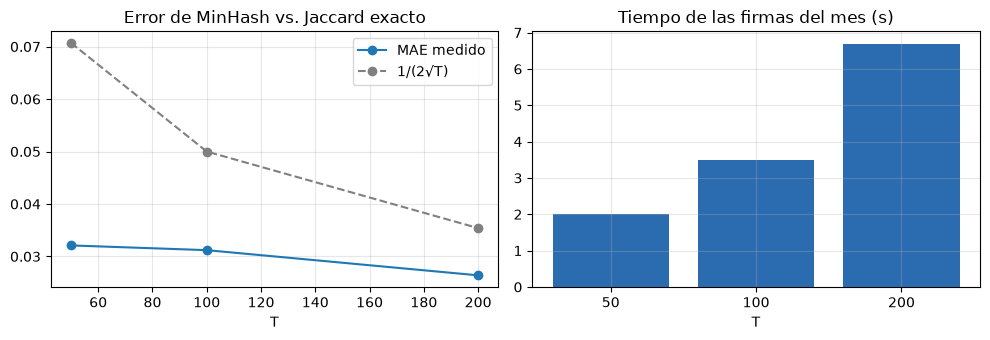

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(tabla_t["T"], tabla_t["MAE"], marker="o", label="MAE medido")
ax[0].plot(tabla_t["T"], tabla_t["error_teorico"], marker="o", ls="--", color="gray", label="1/(2√T)")
ax[0].set_xlabel("T"); ax[0].set_title("Error de MinHash vs. Jaccard exacto"); ax[0].legend()
ax[1].bar(tabla_t["T"].astype(str), tabla_t["seg_firmas"], color="#2b6cb0")
ax[1].set_xlabel("T"); ax[1].set_title("Tiempo de las firmas del mes (s)")
mostrar_fig("firma_T")

- El error de MinHash casi no cambia entre `T` = 50 y 100 (0.032 y 0.031) y baja a 0.026 con 200; en los tres está bajo la cota 1/(2√T)

- El tiempo de las firmas crece lineal con `T` (2.0 → 3.5 → 6.7 s en el mes)

- Con `T` = 50 la precision sube a 0.95 sin perder pares, porque su umbral LSH (0.85) está más cerca de 0.90; ese margen chico es el riesgo de perder pares de 0.90–0.92 en otros meses

- Se mantiene `T = 100`: umbral LSH 0.79 con margen sobre 0.90 y error 0.031

### 5. Experimento: número de cubetas

- Con `(B, R)` fijo, la cubeta de cada banda pasa a ser `hash mod n_cubetas`: con 100 y 10,000 cubetas frente a las 2³² del hash

- Menos cubetas = más colisiones accidentales entre bandas distintas = más candidatos falsos que hay que verificar

In [15]:
EXP_CUBETAS = [100, 10_000, None]   # pocas, intermedias y las 2³² del hash sin módulo (la usada en c_pares)
tabla_c = pd.DataFrame([{"cubetas": n_ if n_ else "2^32", **metricas_lsh(B, R, n_cubetas=n_)} for n_ in EXP_CUBETAS])
tabla_c

,cubetas,b,r,umbral_lsh,candidatos,GT,TP,FP,FN,precision,recall,F1,seg
0,100,10,10,0.794,30309,8334,8334,21975,0,0.2750,1.0,0.4313,1.1
1,10000,10,10,0.794,10307,8334,8334,1973,0,0.8086,1.0,0.8942,0.8
2,2^32,10,10,0.794,10209,8334,8334,1875,0,0.8163,1.0,0.8989,0.7


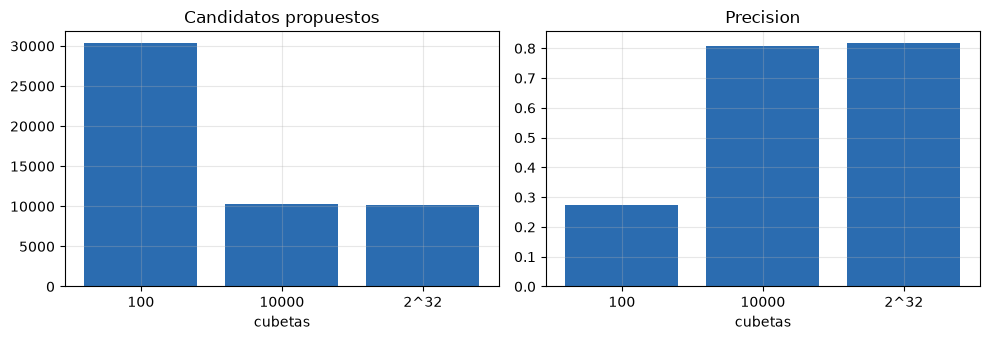

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = tabla_c["cubetas"].astype(str)
ax[0].bar(x, tabla_c["candidatos"], color="#2b6cb0"); ax[0].set_title("Candidatos propuestos"); ax[0].set_xlabel("cubetas")
ax[1].bar(x, tabla_c["precision"], color="#2b6cb0"); ax[1].set_title("Precision"); ax[1].set_xlabel("cubetas")
mostrar_fig("cubetas")

- El recall no cambia (100% en los tres): una colisión de cubeta agrega candidatos, nunca los quita

- Con 100 cubetas los candidatos se triplican (30,309) y la precision cae a 0.28; con 10,000 ya es casi igual a las 2³² del hash (10,307 vs 10,209)

- El filtro de misma entidad y ventana limita el daño: solo colisionan procesos que ya eran comparables

### 6. Experimento: umbral de Jaccard (`UMBRAL`)

Con `(B, R)` fijo, cuántos pares reales hay y cuántos encuentra LSH si el umbral de "casi idéntico" fuera 0.80, 0.90 o 0.95

In [17]:
EXP_UMBRAL = [0.80, 0.90, 0.95]   # más laxo, actual y más estricto
tabla_u = pd.DataFrame([{"UMBRAL": u_, **metricas_lsh(B, R, umbral=u_)} for u_ in EXP_UMBRAL])
tabla_u

,UMBRAL,b,r,umbral_lsh,candidatos,GT,TP,FP,FN,precision,recall,F1,seg
0,0.80,10,10,0.794,10209,8531,8510,1699,21,0.8336,0.9975,0.9082,0.7
1,0.90,10,10,0.794,10209,8334,8334,1875,0,0.8163,1.0000,0.8989,0.6
2,0.95,10,10,0.794,10209,8290,8290,1919,0,0.8120,1.0000,0.8963,0.6


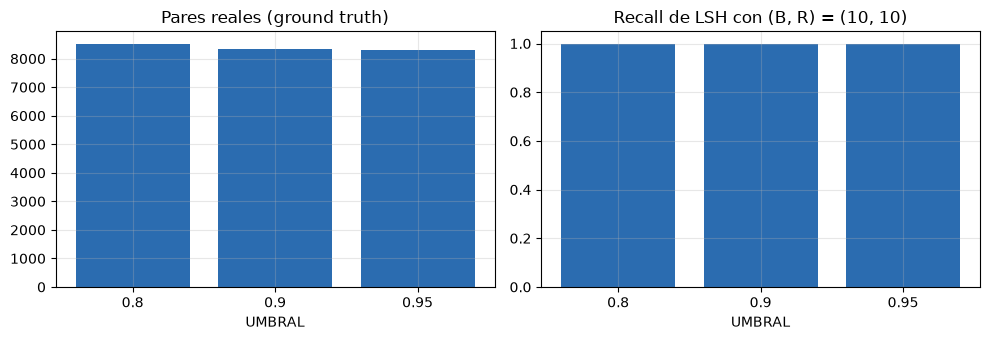

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = tabla_u["UMBRAL"].astype(str)
ax[0].bar(x, tabla_u["GT"], color="#2b6cb0"); ax[0].set_title("Pares reales (ground truth)"); ax[0].set_xlabel("UMBRAL")
ax[1].bar(x, tabla_u["recall"], color="#2b6cb0"); ax[1].set_title(f"Recall de LSH con (B, R) = ({B}, {R})"); ax[1].set_xlabel("UMBRAL")
mostrar_fig("umbral")

- Con `UMBRAL` = 0.80 el umbral queda casi sobre el de LSH (0.79): aparecen 197 pares reales más y LSH pierde 21 (recall 99.75%)

- Con 0.95 los pares reales bajan solo 0.5% (8,334 → 8,290): la mayoría tiene texto idéntico (Jaccard = 1)

- Se mantiene 0.90: el resultado casi no depende del umbral entre 0.90 y 0.95, y LSH no pierde pares

### 7. Pares verificados del mes con `(B, R)`

In [19]:
pares_m = verificar_pares(candidatos_lsh(lsh_bandas(firmas_m), ANIO_CHK, MES_CHK), procesos.where(filtro_meses(ANIO_CHK, MES_CHK)), firmas_m).cache()
n_pm = pares_m.count()
assert n_pm <= n_pos
print(f"Pares ≥ {UMBRAL} vía LSH: {n_pm:,} de {n_pos:,} exactos ({n_pm / max(n_pos, 1):.1%})")
pares_m.orderBy(F.desc("jaccard"), "dias_diferencia").select("entidad", "fecha_1", "fecha_2", "dias_diferencia", "jaccard", "minhash_sim", "tramo_1", "tramo_2", "tramo_suma").show(10, truncate=35)

def monto(x):
    return f"{x:,.0f}" if x is not None else "sin monto"

ej = pares_m.where(~F.col("texto_identico")).orderBy(F.desc("jaccard")).first() or pares_m.first()
if ej:
    print(f"{ej['entidad']} | {ej['fecha_1']:%Y-%m-%d} → {ej['fecha_2']:%Y-%m-%d} ({ej['dias_diferencia']} días) | Jaccard {ej['jaccard']} | MinHash {ej['minhash_sim']}")
    print(f"Montos {monto(ej['monto_final_1'])} + {monto(ej['monto_final_2'])} = {monto(ej['monto_suma'])} ({ej['tramo_1']} + {ej['tramo_2']} → {ej['tramo_suma']})")
    print(f"[1] {ej['descripcion_1'][:250]}\n[2] {ej['descripcion_2'][:250]}")

Pares ≥ 0.9 vía LSH: 8,334 de 8,334 exactos (100.0%)


+-----------------------------------+-------------------+-------------------+---------------+-------+-----------+-----------+----------+-----------+
|                            entidad|            fecha_1|            fecha_2|dias_diferencia|jaccard|minhash_sim|    tramo_1|   tramo_2| tramo_suma|
+-----------------------------------+-------------------+-------------------+---------------+-------+-----------+-----------+----------+-----------+
|GOBIERNO REGIONAL DE SAN MARTIN ...|2024-06-06 00:00:00|2024-06-06 00:00:00|              0|    1.0|        1.0| 2_50k-200k|2_50k-200k| 2_50k-200k|
|INSTITUTO DE VIALIDAD MUNICIPAL ...|2024-06-06 00:00:00|2024-06-06 00:00:00|              0|    1.0|        1.0| 2_50k-200k|2_50k-200k|  3_200k-1M|
|INPE-OFICINA GENERAL DE INFRAEST...|2024-06-17 00:00:00|2024-06-17 00:00:00|              0|    1.0|        1.0|      5_>5M|     5_>5M|      5_>5M|
|UNIDAD EJECUTORA 008:PROYECTOS E...|2024-06-17 00:00:00|2024-06-17 00:00:00|              0|    1.0|     

### 8. Escritura de resultados

Tablas de los experimentos en `temp/b_lsh/tablas` (parquet) y `web/` (json)

In [20]:
resumen = pd.DataFrame([{"anio": ANIO_CHK, "mes": MES_CHK, "pares_fuerza_bruta": n_gt, "pares_reales": n_pos,
                         "pares_lsh_verificados": n_pm, "B": B, "R": R}])
tablas = {"configs_br": tabla, "longitud_T": tabla_t, "cubetas": tabla_c.astype({"cubetas": str}), "umbral": tabla_u, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/b_lsh/: {', '.join(escritos)}")

Escrito en temp/b_lsh/: configs_br, longitud_T, cubetas, umbral, resumen


#### a. Verificación

In [21]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 5 tablas (parquet + json) | 5 figuras: cubetas, curva_s, firma_T, lsh_configs, umbral


---
### 9. Cerrar sesión

In [22]:
spark.stop()